In [ ]:
import sys
sys.path.insert(1, '/Users/inuit/Documents/Gitrepos/Classified/datasets')

from apply_imagenet100 import load_image100_data, make_predictions, train_model
train_dataloader, train_labels_dict = load_image100_data(train=True)
val_dataloader, val_labels_dict = load_image100_data(train=False)

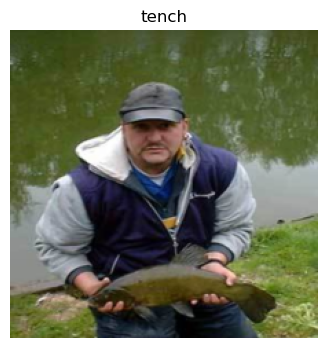

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

batch_imgs, batch_labels = next(iter(train_dataloader)) 

# Path and label for the first sample
img_path = batch_imgs[0]
label_idx = batch_labels[0]

# Convert tensor (C, H, W) -> (H, W, C) and unnormalize to [0,1]
img_tensor = img_path.cpu().detach()
img_np = img_tensor.numpy().transpose(1, 2, 0)
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_np = (img_np * std) + mean
img_np = np.clip(img_np, 0.0, 1.0)

class_name = train_labels_dict[int(label_idx)]

plt.figure(figsize=(4, 4))
plt.imshow(img_np)
title = f"Label: {int(label_idx)}"
plt.title(class_name)
plt.axis('off')
plt.show()

In [ ]:
import torch

# load models trained on imagenet1k
model = torch.hub.load("pytorch/vision", "resnet50", weights="IMAGENET1K_V1")
assert model.fc.out_features == 1000, "Expected 1000 output features for imagenet1k pretrained model"

if torch.backends.mps.is_available():
        device = torch.device("mps")
elif torch.cuda.is_available():
        device = torch.device("cuda")
else:
        device = torch.device("cpu")

model = model.to(device)
model.eval()

results = make_predictions(model, val_dataloader, val_labels_dict, max_batches=1, topk=5)

# Print human-readable results for the first batch
for i, r in enumerate(results):
    print(f"Sample {i}: true [{r['true_idx']}] {r['true_name']}")
    preds = ", ".join([f"(idx={idx}, p={p:.3f})" for idx, p in zip(r['topk_idxs'], r['topk_probs'])])
    print("  Top-5 (ImageNet-1k index, prob):", preds)
    print()

Using cache found in /Users/inuit/.cache/torch/hub/pytorch_vision_main


Sample 0: true [46] green_lizard
  Top-5 (ImageNet-1k index, prob): (idx=46, p=0.641), (idx=40, p=0.200), (idx=31, p=0.056), (idx=32, p=0.019), (idx=47, p=0.012)

Sample 1: true [67] diamondback
  Top-5 (ImageNet-1k index, prob): (idx=68, p=0.585), (idx=66, p=0.317), (idx=67, p=0.054), (idx=60, p=0.037), (idx=54, p=0.003)

Sample 2: true [11] goldfinch
  Top-5 (ImageNet-1k index, prob): (idx=10, p=0.945), (idx=11, p=0.032), (idx=301, p=0.009), (idx=86, p=0.002), (idx=92, p=0.001)

Sample 3: true [130] flamingo
  Top-5 (ImageNet-1k index, prob): (idx=130, p=0.999), (idx=99, p=0.000), (idx=100, p=0.000), (idx=134, p=0.000), (idx=932, p=0.000)

Sample 4: true [26] common_newt
  Top-5 (ImageNet-1k index, prob): (idx=126, p=0.176), (idx=79, p=0.161), (idx=114, p=0.105), (idx=27, p=0.078), (idx=26, p=0.074)

Sample 5: true [52] thunder_snake
  Top-5 (ImageNet-1k index, prob): (idx=52, p=0.922), (idx=60, p=0.043), (idx=53, p=0.008), (idx=58, p=0.006), (idx=57, p=0.004)

Sample 6: true [115] s

In [ ]:
len(train_dataloader)

In [ ]:
train_model(model, train_dataloader, epochs=2)

[Epoch 1, Batch 100] Loss: 5.6193
[Epoch 1, Batch 300] Loss: 9.1131
[Epoch 1, Batch 500] Loss: 8.9361
[Epoch 1, Batch 700] Loss: 8.8327


KeyboardInterrupt: 

In [ ]:
import torch.nn as nn

import torch.optim as optim

device = torch.device("mps")
model = model.to(device)
model.train()

train_losses = []
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()
for batch_i, (imgs, labels) in enumerate(val_dataloader):
    labels = labels.to(device, non_blocking=True)
    imgs = imgs.to(device, non_blocking=True)
    optimizer.zero_grad()
    outputs = model(imgs)                      # (B, 1000)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())
        # free
    del outputs, loss
    try:
        torch.mps.empty_cache()
    except Exception:
        pass